# Comparison of heating rates across trajectories

Reads `generated_energy.dat` (WinNet's per-reaction-type heating output) from every
`traj*.dat` run folder under `Runs/Trajectories_144/Example_NSM_dyn_ejecta_144_trajectories/`
and overlays each run's **total heating rate vs. time** on one plot, so the spread across
the 144-trajectory set can be compared directly.

Many of the 144 runs did not finish (some never produced `generated_energy.dat`, others
stopped early or have a truncated last line) — this notebook skips/repairs those cases
rather than failing, and reports how many trajectories made it into the plot.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import glob
import os
import re

In [2]:
TRAJ_DIR        = 'Runs/Hypatia_calculations/Example_NSM_dyn_ejecta_4_trajectories/'
ENERGY_FILENAME = 'generated_energy.dat'

# Column layout of generated_energy.dat (WinNet):
# time[s]  Engen(Total)  S_src  Engen(weak)  Engen(n,g)  Engen(p,g)
# Engen(a,g)  Engen(n,p)  Engen(n,a)  Engen(p,a)  Engen(fiss)      [erg/g/s]
ENERGY_COLUMNS = [
    'time', 'Engen_total', 'S_src', 'Engen_weak', 'Engen_ng', 'Engen_pg',
    'Engen_ag', 'Engen_np', 'Engen_na', 'Engen_pa', 'Engen_fiss',
]

In [3]:
traj_dirs = sorted(
    glob.glob(os.path.join(TRAJ_DIR, 'traj*.dat')),
    key=lambda p: int(re.search(r'traj(\d+)\.dat', os.path.basename(p)).group(1))
)
print(f"Found {len(traj_dirs)} trajectory folders")

Found 4 trajectory folders


## Robust reader
A run that was killed mid-write can leave `generated_energy.dat` with a truncated final line (fewer fields than expected). `pandas` pads those with `NaN` rather than raising, so we just read with a whitespace parser and drop any incomplete rows.

In [4]:
def load_generated_energy(path):
    """Read one trajectory's generated_energy.dat.

    Returns a DataFrame with columns ENERGY_COLUMNS, or None if the file is
    missing, empty, or unreadable (e.g. the run never got far enough to write it).
    """
    if not os.path.isfile(path):
        return None
    try:
        df = pd.read_csv(
            path, sep=r'\s+', comment='#', header=None,
            names=ENERGY_COLUMNS, engine='python',
        )
    except Exception:
        return None
    df = df.dropna()          # drop any truncated/incomplete trailing row(s)
    if df.empty:
        return None
    return df.reset_index(drop=True)

In [5]:
runs = {}          # {traj_id: DataFrame}
missing, unreadable = [], []

for traj_path in traj_dirs:
    traj_id = int(re.search(r'traj(\d+)\.dat', os.path.basename(traj_path)).group(1))
    energy_path = os.path.join(traj_path, ENERGY_FILENAME)
    df = load_generated_energy(energy_path)
    if df is None:
        (missing if not os.path.isfile(energy_path) else unreadable).append(traj_id)
        continue
    runs[traj_id] = df

print(f"Total trajectories found:      {len(traj_dirs)}")
print(f"Loaded (usable heating curve): {len(runs)}")
print(f"Missing generated_energy.dat:  {len(missing)}")
print(f"Present but empty/unreadable:  {len(unreadable)}")

Total trajectories found:      4
Loaded (usable heating curve): 4
Missing generated_energy.dat:  0
Present but empty/unreadable:  0


## Comparison plot: total heating rate vs. time

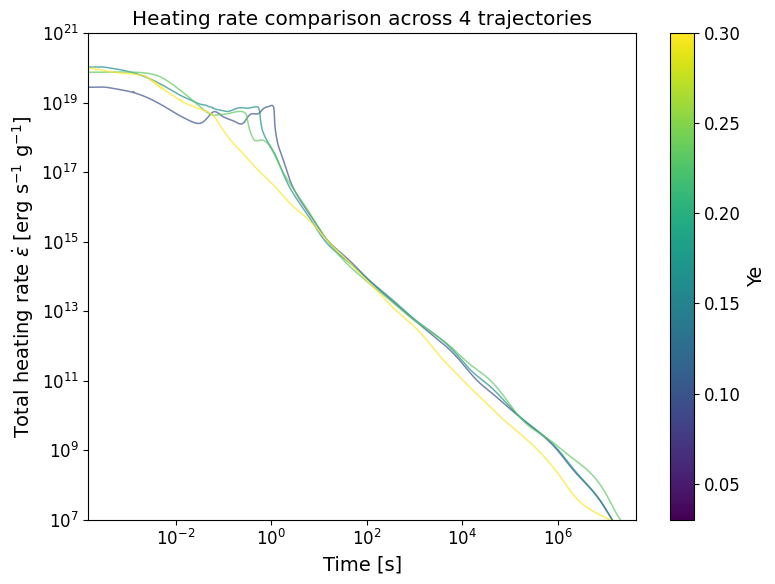

In [10]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=0.03, vmax=0.3)

fig, ax = plt.subplots(figsize=(8, 6))
for traj_id, df in sorted(runs.items()):
    mask = df['time'] > 0   # drop the t=0 row so it survives a log-x axis
    ax.plot(
        df['time'][mask], df['Engen_total'][mask],
        color=cmap(norm(int(traj_id)*0.0675+0.03)), alpha=0.7, linewidth=1.1,
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(left=1.5e-4, right=4.32e7)
ax.set_ylim(bottom=1e7, top=1e21)
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'Total heating rate $\dot\varepsilon$ [erg s$^{-1}$ g$^{-1}$]')
ax.set_title(f'Heating rate comparison across {len(runs)} trajectories')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Ye')

fig.tight_layout()
fig.savefig('heating_rate_comparison.pdf', bbox_inches='tight', dpi=300)